In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

daily=pd.read_csv(r'C:\Users\hp\afficionado_forecasting\data\daily_features.csv')
daily['date'] = pd.to_datetime(daily['date'])
daily= daily.sort_values(['store_location','date']).reset_index(drop=True)

print("Loaded:", daily.shape)
print("Data range:", daily['date'].min(), "to", daily['date'].max())
print("Stores:", daily['store_location'].unique())

Loaded: (453, 20)
Data range: 2025-01-31 00:00:00 to 2025-06-30 00:00:00
Stores: <ArrowStringArray>
['Astoria', 'Hell's Kitchen', 'Lower Manhattan']
Length: 3, dtype: str


In [3]:
cutoff = daily['date'].max() - pd.Timedelta(days=30)
train = daily[daily['date'] <= cutoff].copy()
test = daily[daily['date'] > cutoff].copy()

print("Cutoff date:", cutoff)
print("Train size:", len(train), "rows |", train['date'].min(), "to", train['date'].max())
print("Test size:", len(test), "rows |", test['date'].min(), "to", test['date'].max())

Cutoff date: 2025-05-31 00:00:00
Train size: 363 rows | 2025-01-31 00:00:00 to 2025-05-31 00:00:00
Test size: 90 rows | 2025-06-01 00:00:00 to 2025-06-30 00:00:00


In [4]:
#evaluation
def evaluate(y_true, y_pred, model_name, store):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{model_name:30s} | {store:20s} | MAE={mae:.1f} | RMSE={rmse:.1f} | MAPE={mape:.1f}%')
    return {'model': model_name, 'store':store, 'MAE':mae, 'RMSE': rmse, 'MAPE':mape}

results = []

In [5]:
print("=" * 75)
print("BASELINE - Naive Forecast")
print("=" * 75)

for store in daily['store_location'].unique():
    tr=train[train['store_location'] == store]
    te=test[test['store_location'] == store].copy()
    te['naive_pred'] = tr['total_revenue'].iloc[-1]

    r=evaluate(te['total_revenue'], te['naive_pred'], 'Naive', store)
    results.append(r)

BASELINE - Naive Forecast
Naive                          | Astoria              | MAE=254.3 | RMSE=324.8 | MAPE=13.2%
Naive                          | Hell's Kitchen       | MAE=539.2 | RMSE=612.5 | MAPE=26.7%
Naive                          | Lower Manhattan      | MAE=257.3 | RMSE=324.8 | MAPE=13.5%


In [6]:
#7 day moving average
print("="*75)
print("BASELINE - 7-Day Moving Average")
print("="*75)

for store in daily['store_location'].unique():
    tr = train[train['store_location'] == store]
    te = test[test['store_location'] == store].copy()

    ma7_pred = tr['total_revenue'].tail(7).mean()
    te['ma7_pred'] = ma7_pred

    r = evaluate(te['total_revenue'], te['ma7_pred'], 'Moving Average 7d', store)
    results.append(r)

BASELINE - 7-Day Moving Average
Moving Average 7d              | Astoria              | MAE=253.5 | RMSE=324.0 | MAPE=13.2%
Moving Average 7d              | Hell's Kitchen       | MAE=485.9 | RMSE=563.3 | MAPE=23.9%
Moving Average 7d              | Lower Manhattan      | MAE=228.9 | RMSE=286.7 | MAPE=12.6%


In [7]:
from prophet import Prophet

print("="*75)
print("PROPHET MODEL")
print("="*75)

prophet_forecasts = {}

for store in daily['store_location'].unique():
    tr = train[train['store_location'] == store][['date','total_revenue']].rename(
        columns={'date':'ds','total_revenue':'y'})
    te = test[test['store_location'] == store][['date','total_revenue']].rename(
        columns={'date':'ds','total_revenue':'y'})

    m = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
    )
    m.fit(tr)

    future=m.make_future_dataframe(periods=30)
    forecast=m.predict(future)

    test_forecast = forecast[forecast['ds'].isin(te['ds'])][['ds','yhat','yhat_lower','yhat_upper']]
    prophet_forecasts[store] = (te, test_forecast)

    r = evaluate(te['y'].values, test_forecast['yhat'].values, 'Prophet',store)
    results.append(r)

19:29:13 - cmdstanpy - INFO - Chain [1] start processing


PROPHET MODEL


19:29:14 - cmdstanpy - INFO - Chain [1] done processing
19:29:14 - cmdstanpy - INFO - Chain [1] start processing
19:29:14 - cmdstanpy - INFO - Chain [1] done processing


Prophet                        | Astoria              | MAE=249.1 | RMSE=304.9 | MAPE=14.3%
Prophet                        | Hell's Kitchen       | MAE=268.6 | RMSE=327.8 | MAPE=14.3%


19:29:14 - cmdstanpy - INFO - Chain [1] start processing
19:29:14 - cmdstanpy - INFO - Chain [1] done processing


Prophet                        | Lower Manhattan      | MAE=226.8 | RMSE=295.3 | MAPE=13.6%


In [8]:
#XGBoost model
from xgboost import XGBRegressor

print("="*75)
print("XGBOOST MODEL")
print("="*75)

features = ['day_of_week','is_weekend','month','week_of_year','day_of_month',
            'lag_1','lag_7','lag_14','roll_7d','roll_14d','roll_30d',
            'store_Astoria','store_Hell\'s Kitchen','store_Lower Manhattan']
X_train = train[features]
Y_train = train['total_revenue']
X_test = test[features]
Y_test = test['total_revenue']

xgb = XGBRegressor(n_estimators=500, learning_rate=0.05,
                   max_depth=4, random_state=42)
xgb.fit(X_train, Y_train,
        eval_set=[(X_test, Y_test)],
        verbose=False)
test = test.copy()
test['xgb_pred'] = xgb.predict(X_test)

for store in daily['store_location'].unique():
    te_s = test[test['store_location'] == store]
    r=evaluate(te_s['total_revenue'], te_s['xgb_pred'], 'XGBoost', store)
    results.append(r)

XGBOOST MODEL
XGBoost                        | Astoria              | MAE=319.1 | RMSE=397.4 | MAPE=16.4%
XGBoost                        | Hell's Kitchen       | MAE=398.2 | RMSE=499.6 | MAPE=19.2%
XGBoost                        | Lower Manhattan      | MAE=273.3 | RMSE=331.0 | MAPE=14.3%


In [9]:
#comparison between results
print("\n" + "=" * 75)
print("FULL RESULTS SUMMARY")
print("="*75)
results = pd.DataFrame(results)
print(results.sort_values(['store','MAE']).to_string(index=False))

print("\nBest model per store (lowest MAPE):")
print(results.loc[results.groupby('store')['MAPE'].idxmin()][['store','model','MAPE']].to_string(index=False))



FULL RESULTS SUMMARY
            model           store        MAE       RMSE      MAPE
          Prophet         Astoria 249.120561 304.883055 14.274556
Moving Average 7d         Astoria 253.544238 324.027575 13.203601
            Naive         Astoria 254.313000 324.757517 13.238185
          XGBoost         Astoria 319.137292 397.414135 16.446817
          Prophet  Hell's Kitchen 268.611225 327.751541 14.347861
          XGBoost  Hell's Kitchen 398.176684 499.599999 19.202643
Moving Average 7d  Hell's Kitchen 485.852667 563.274761 23.893176
            Naive  Hell's Kitchen 539.166000 612.466234 26.684787
          Prophet Lower Manhattan 226.806468 295.285715 13.570449
Moving Average 7d Lower Manhattan 228.933857 286.687467 12.577831
            Naive Lower Manhattan 257.313000 324.791860 13.483169
          XGBoost Lower Manhattan 273.287650 330.984760 14.289595

Best model per store (lowest MAPE):
          store             model      MAPE
        Astoria Moving Average 7d 13.20

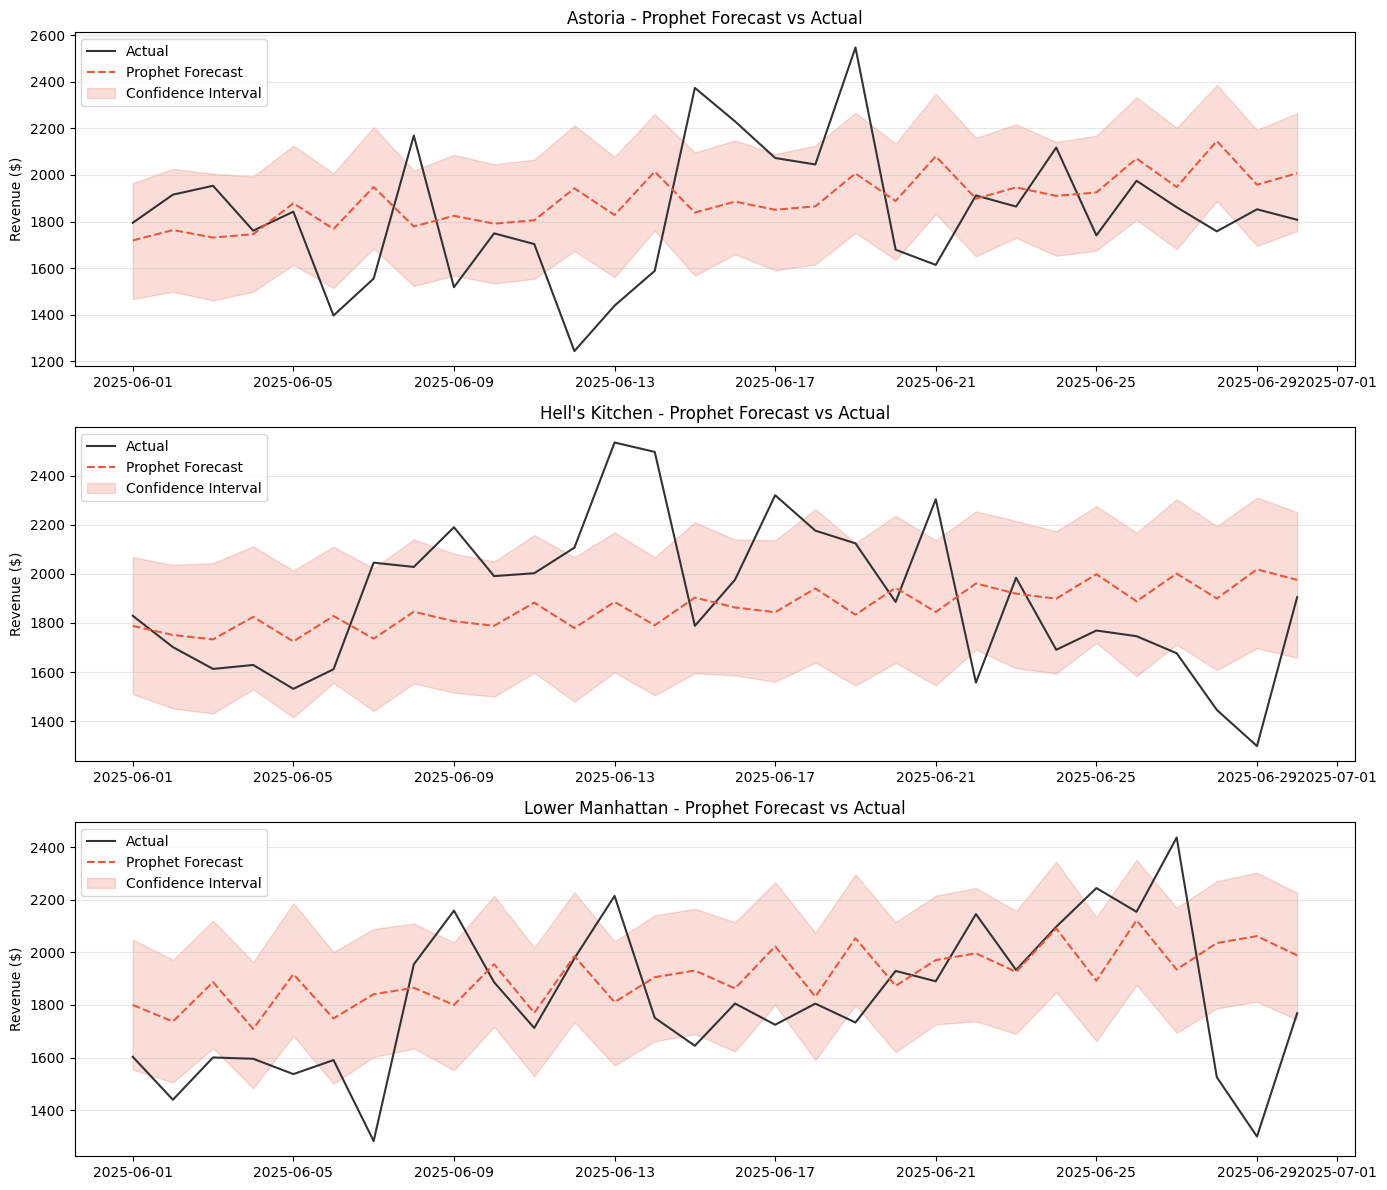

In [10]:
#prophet forecasts vs actuals
fig, axes = plt.subplots(3,1, figsize=(14,12))
for i, store in enumerate(daily['store_location'].unique()):
    te, fc = prophet_forecasts[store]

    axes[i].plot(te['ds'].values, te['y'].values,
                label='Actual',color='#333333', linewidth=1.5)
    axes[i].plot(fc['ds'].values, fc['yhat'].values,
                label='Prophet Forecast',color='#E8593C', linewidth=1.5, linestyle='--')
    axes[i].fill_between(fc['ds'].values,
                          fc['yhat_lower'].values, fc['yhat_upper'].values,
                          alpha=0.2, color='#E8593C', label='Confidence Interval')
    axes[i].set_title(f'{store} - Prophet Forecast vs Actual')
    axes[i].set_ylabel('Revenue ($)')
    axes[i].legend()
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/prophet_forecasts.png')
plt.show()

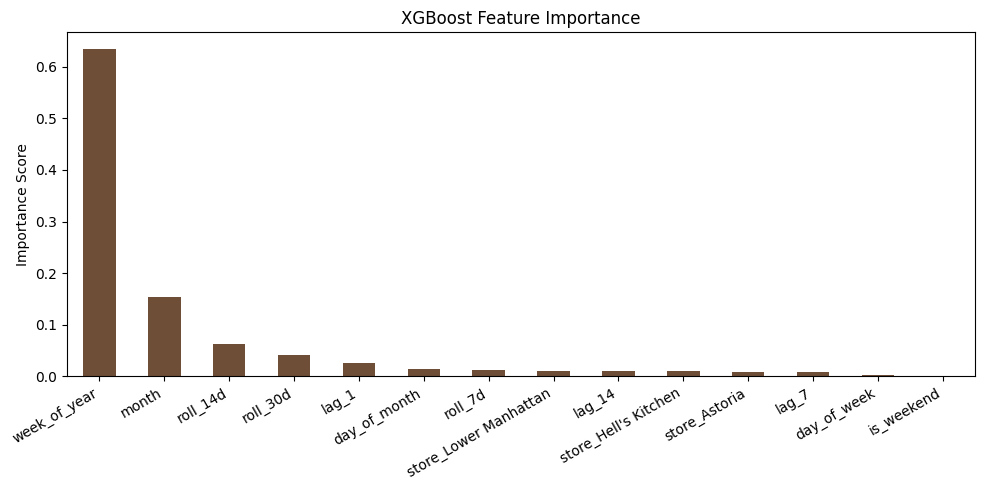


Top 5 most important features:
week_of_year    0.634640
month           0.153988
roll_14d        0.063181
roll_30d        0.041488
lag_1           0.026761
dtype: float32


In [11]:
#feature importance
feat_imp = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,5))
feat_imp.plot(kind='bar', color='#6F4E37')
plt.title('XGBoost Feature Importance')
plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('data/feature_importance.png')
plt.show()

print("\nTop 5 most important features:")
print(feat_imp.head(5))

In [12]:
#prediction interval
print("Prediction Interval Width Analysis")
print("="*50)

for store in daily['store_location'].unique():
    te, fc = prophet_forecasts[store]
    fc['interval_width'] = fc['yhat_upper'] - fc['yhat_lower']
    avg_width = fc['interval_width'].mean()
    avg_pred = fc['yhat'].mean()
    uncertainty_pct = (avg_width / avg_pred)* 100
    print(f"{store:20s} | Avg forecast: ${avg_pred:.0f} "
          f"| Interval width: ${avg_width:.0f} "
          f"| Uncertainity: {uncertainty_pct:.1f}%")

Prediction Interval Width Analysis
Astoria              | Avg forecast: $1892 | Interval width: $508 | Uncertainity: 26.9%
Hell's Kitchen       | Avg forecast: $1863 | Interval width: $582 | Uncertainity: 31.2%
Lower Manhattan      | Avg forecast: $1911 | Interval width: $486 | Uncertainity: 25.4%


In [13]:
print("\nScenario Planning for Next 30 Days")
print("=" * 50)

scenario_results = []

for store in daily['store_location'].unique():
    te, fc = prophet_forecasts[store]
    expected = fc['yhat'].sum()
    best_case = fc['yhat_upper'].sum() * 1.10
    worst_case = fc['yhat_lower'].sum() * 0.90

    scenario_results.append({
        'Store': store,
        'Worst Case ($)': round(worst_case),
        'Expected ($)': round(expected),
        'Best Case ($)': round(best_case)
    })

    print(f"\n{store}")
    print(f" Worst Case : ${worst_case:,.0f}")
    print(f" Expected : ${expected:,.0f}")
    print(f" Best Case : ${best_case:,.0f}")

scenario_df = pd.DataFrame(scenario_results)


Scenario Planning for Next 30 Days

Astoria
 Worst Case : $44,206
 Expected : $56,765
 Best Case : $70,803

Hell's Kitchen
 Worst Case : $42,367
 Expected : $55,896
 Best Case : $70,988

Lower Manhattan
 Worst Case : $45,057
 Expected : $57,331
 Best Case : $71,099


In [15]:
#demand spike
print("\n Demand Spike Sensitivity Analysis")
print("=" * 50)

avg_daily_rev = daily.groupby('store_location')['total_revenue'].mean()
avg_daily_qty = daily.groupby('store_location')['total_qty'].mean()

spike_levels = [1.0, 1.15, 1.30, 1.50]

print(f"\n{'Store': <20} {'Normal': >10} {'+15%':>10} {'+30%':>10} {'+50%':>10}")
print("-" * 60)

for store in daily['store_location'].unique():
    base_qty = avg_daily_qty[store]
    row = f"{store:<20}"
    for spike in spike_levels:
        row += f"{base_qty * spike:>9.0f}"
    print(row)

print("\n(Values = estimated daily transactions quantity)")
print("Use this to plan minimum staff per shift during promotions or events")


 Demand Spike Sensitivity Analysis

Store                    Normal       +15%       +30%       +50%
------------------------------------------------------------
Astoria                   417      479      542      625
Hell's Kitchen            421      484      548      632
Lower Manhattan           422      485      548      633

(Values = estimated daily transactions quantity)
Use this to plan minimum staff per shift during promotions or events


In [17]:
#peak hour risk
print("\nPeak Hour Staffing Risk by Store")
print("=" * 50)

df_orig = pd.read_csv(r'C:\Users\hp\afficionado_forecasting\data\transactions.csv')
df_orig['transaction_time'] = pd.to_datetime(df_orig['transaction_time'], format = '%H:%M:%S')
df_orig['hour'] = df_orig['transaction_time'].dt.hour

hourly_store = df_orig.groupby(['store_location','hour'])['transaction_id'].count().reset_index()
hourly_store.columns = ['store_location','hour','avg_transactions']

hourly_store['is_peak'] = hourly_store.groupby('store_location')['avg_transactions'].transform(
    lambda x: x >= x.quantile(0.75))

print("\nPeak hours per store (top 25% busiest):")
for store in hourly_store['store_location'].unique():
    peaks = hourly_store[(hourly_store['store_location'] == store) & 
                          (hourly_store['is_peak'] == True)]['hour'].tolist()
    print(f" {store:20s}: hours {peaks}")


Peak Hour Staffing Risk by Store

Peak hours per store (top 25% busiest):
 Astoria             : hours [7, 8, 9, 10]
 Hell's Kitchen      : hours [8, 9, 10, 11]
 Lower Manhattan     : hours [7, 8, 9, 10]


In [19]:
#saving all results
daily['date'] = daily['date'].astype(str)

scenario_df.to_csv(r'C:\Users\hp\afficionado_forecasting\data\scenarios.csv', index=False)
results.to_csv(r'C:\Users\hp\afficionado_forecasting\data\model_results.csv', index=False)
hourly_store.to_csv(r'C:\Users\hp\afficionado_forecasting\data\peak_hours.csv', index=False)

print("All outputs saved!")
print("\nFiles ready for dashboard:")
print(" - daily_features.csv")
print(" - model_results.csv")
print(" - scenarios.csv")
print(" - peak_hours.csv")

All outputs saved!

Files ready for dashboard:
 - daily_features.csv
 - model_results.csv
 - scenarios.csv
 - peak_hours.csv
